<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Training a real CNN with PyTorch</b>
</h1>
<div style="font-family:'Times New Roman';">
Now i let the network learn its own filters instead of me picking sobel kernels by hand. I train a small CNN on the digits dataset, compare it against a plain dense net, and then actualy look at what filters it ended up learning.
</div>

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

torch.manual_seed(0)
np.random.seed(0)

In [2]:
digits = load_digits()
X = digits.images / 16.0          # scale 0..16 down to 0..1
y = digits.target

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=0)

# pytorch conv wants shape (N, channels, H, W)
Xtr_t = torch.tensor(Xtr, dtype=torch.float32).unsqueeze(1)
Xte_t = torch.tensor(Xte, dtype=torch.float32).unsqueeze(1)
ytr_t = torch.tensor(ytr, dtype=torch.long)
yte_t = torch.tensor(yte, dtype=torch.long)

print('train', Xtr_t.shape, ' test', Xte_t.shape)

train torch.Size([1347, 1, 8, 8])  test torch.Size([450, 1, 8, 8])


## the CNN

one conv layer that learns 8 filters, then relu, max pool, flatten, and a dense layer for the 10 classes. i build it with Sequential so its just a stack of layers.

In [3]:
cnn = nn.Sequential(
    nn.Conv2d(1, 8, kernel_size=3, padding=1),  # 8 learned filters
    nn.ReLU(),
    nn.MaxPool2d(2),                            # 8x8 -> 4x4
    nn.Flatten(),
    nn.Linear(8 * 4 * 4, 10)
)
print(cnn)

Sequential(
  (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Flatten(start_dim=1, end_dim=-1)
  (4): Linear(in_features=128, out_features=10, bias=True)
)


## training loop

normal stuff, cross entropy loss with the Adam optimizer, run it for a bunch of epochs and keep the loss so i can plot it.

In [4]:
def train(model, epochs=120, lr=0.01):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    history = []
    for ep in range(epochs):
        opt.zero_grad()
        out = model(Xtr_t)
        loss = loss_fn(out, ytr_t)
        loss.backward()
        opt.step()
        history.append(loss.item())
    return history

hist = train(cnn)
print('final train loss', round(hist[-1], 4))

final train loss 0.0326


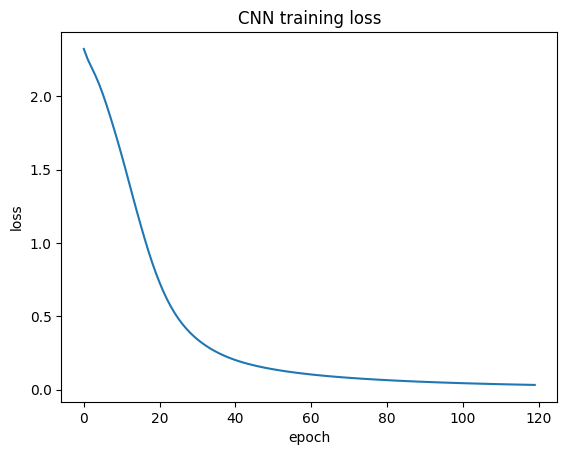

In [5]:
plt.plot(hist)
plt.xlabel('epoch'); plt.ylabel('loss')
plt.title('CNN training loss')
plt.show()

In [6]:
def accuracy(model, Xt, yt):
    model.eval()
    with torch.no_grad():
        pred = model(Xt).argmax(1)
    return (pred == yt).float().mean().item()

print('CNN test accuracy', round(accuracy(cnn, Xte_t, yte_t), 4))

CNN test accuracy 0.9778


## compare against a plain dense net

same data but no convolution, just flatten the 64 pixels straight into a normal hidden layer. on these tiny 8x8 digits both do really well, so the accuracy alone wont look that diffrent. the win of a CNN shows up more on bigger images.

In [7]:
mlp = nn.Sequential(
    nn.Flatten(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 10)
)

train(mlp)
print('MLP test accuracy', round(accuracy(mlp, Xte_t, yte_t), 4))

MLP test accuracy 0.9711


## actual vs predicted

accuracy is one number, lets actualy look at the digits. green title means it got it right, red means wrong. `t` is the true label, `p` is what the CNN predicted.

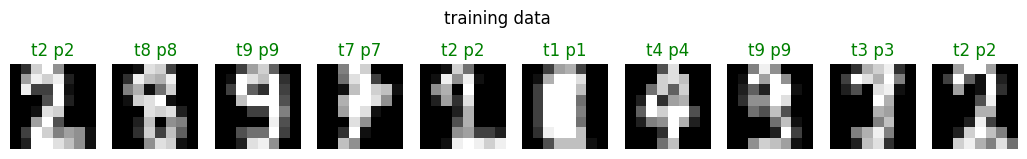

In [8]:
def show_preds(model, Xt, yt, title, n=10):
    model.eval()
    with torch.no_grad():
        pred = model(Xt).argmax(1)
    fig, ax = plt.subplots(1, n, figsize=(13, 2), squeeze=False)
    for i in range(n):
        ax[0][i].imshow(Xt[i, 0], cmap='gray')
        ok = pred[i].item() == yt[i].item()
        ax[0][i].set_title(f't{yt[i].item()} p{pred[i].item()}',
                           color='green' if ok else 'red')
        ax[0][i].axis('off')
    fig.suptitle(title)
    plt.show()

# on the training data
show_preds(cnn, Xtr_t, ytr_t, 'training data')

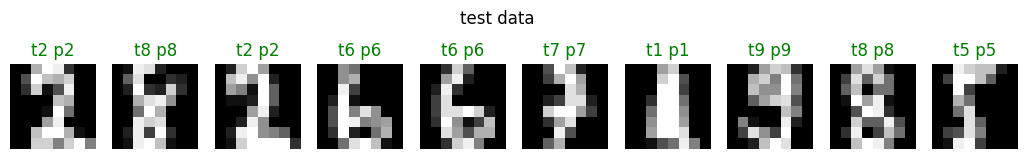

In [9]:
# and on the test data (digits the CNN never saw)
show_preds(cnn, Xte_t, yte_t, 'test data')

misclassified test digits: 10 out of 450


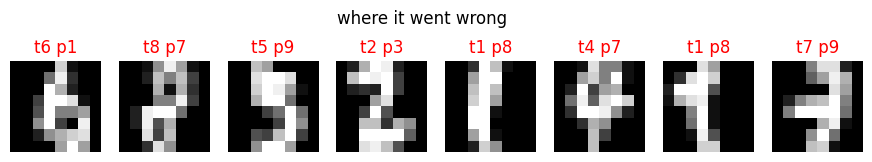

In [10]:
# the ones it actualy got wrong on the test set
with torch.no_grad():
    pred = cnn(Xte_t).argmax(1)
wrong = (pred != yte_t).nonzero().flatten()
print('misclassified test digits:', len(wrong), 'out of', len(yte_t))

n = min(8, len(wrong))
fig, ax = plt.subplots(1, n, figsize=(11, 2), squeeze=False)
for k in range(n):
    idx = wrong[k].item()
    ax[0][k].imshow(Xte_t[idx, 0], cmap='gray')
    ax[0][k].set_title(f't{yte_t[idx].item()} p{pred[idx].item()}', color='red')
    ax[0][k].axis('off')
fig.suptitle('where it went wrong')
plt.show()

most of the misses are the genuinely messy ones, the kind a person might squint at too. thats expected at ~98% accuracy.

## what filters did it learn

in notebook 1 and 2 i hardcoded sobel filters. here nobody told the CNN anything, it figured out its own 8 filters from the data. lets pull them out and look.

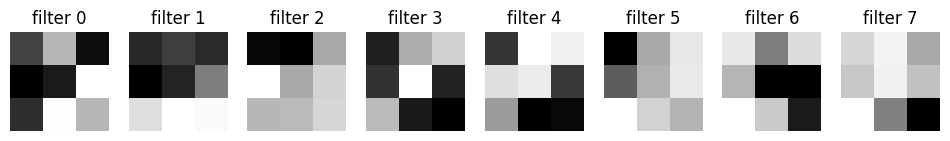

In [11]:
filters = cnn[0].weight.detach().numpy()   # shape (8, 1, 3, 3)

fig, ax = plt.subplots(1, 8, figsize=(12, 2))
for i in range(8):
    ax[i].imshow(filters[i, 0], cmap='gray')
    ax[i].set_title(f'filter {i}')
    ax[i].axis('off')
plt.show()

and the feature maps they make on one test digit, each filter reacts to a diffrent part of the stroke.

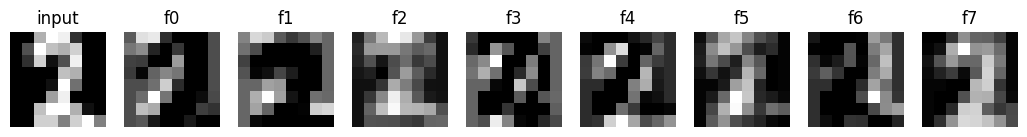

In [12]:
sample = Xte_t[0:1]
with torch.no_grad():
    maps = cnn[1](cnn[0](sample))   # conv then relu
maps = maps[0].numpy()

fig, ax = plt.subplots(1, 9, figsize=(13, 2))
ax[0].imshow(sample[0, 0], cmap='gray'); ax[0].set_title('input'); ax[0].axis('off')
for i in range(8):
    ax[i+1].imshow(maps[i], cmap='gray')
    ax[i+1].set_title(f'f{i}'); ax[i+1].axis('off')
plt.show()

### quick recap

the CNN learned its own filters from scratch and matched the dense net, with way fewer weights in the part that does the seeing (one small kernel slides everywhere instead of a giant weight per pixel). on tiny 8x8 digits the two are close, but the conv idea is what scales up to real images like 28x28 mnist (wich i couldnt download in here) where flattening falls apart.